# 31.1 · Dense class targets and FCN

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain dense class targets and fcn using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[29 · Object Segmentation](../../29-object-segmentation/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Semantic segmentation assigns a category to every pixel. All pixels of the same category share a label even when they belong to separate objects. Dense prediction requires spatially aligned targets, careful loss design and evaluation across classes.

## 2. Intuition

A fully convolutional network replaces image-level classification with spatial logits. For C mutually exclusive classes, logits have shape N×C×H×W and targets typically have integer IDs N×H×W. Binary one-channel segmentation is a special case and uses a different target contract.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 31
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
IoU_c=TP_c/(TP_c+FP_c+FN_c)
$$

TPc counts pixels correctly assigned class c, FPc pixels incorrectly assigned c and FNc missed class-c pixels. Counts 8,2,4 give IoU=8/14. Mean IoU averages class scores under a declared absent-class policy.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
tp, fp, fn = 8.0, 2.0, 4.0
class_iou = tp / (tp + fp + fn)
assert np.isclose(class_iou, 8 / 14)
print(class_iou)

0.5714285714285714


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The baseline is binary semantic segmentation with a shallow U-Net. The same dense-prediction principles extend to C classes by changing head channels, targets and loss together.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def segmentation_lab(lesson, seed, amount):
    configure(seed)
    x, _, masks = shape_data(64, seed=seed)
    test, _, truth = shape_data(12, seed=seed + 1000)
    model = TinyUNet()
    history = train_supervised(
        model, x, masks, epochs=4, lr=0.01 * amount, segmentation=True, seed=seed
    )
    with torch.no_grad():
        probability = torch.sigmoid(model(test))
        predicted = probability > 0.5
    intersection = (predicted * truth.bool()).sum().item()
    union = (predicted | truth.bool()).sum().item()
    dice = 2 * intersection / (predicted.sum().item() + truth.sum().item() + 1e-8)
    return Result(
        "29/31 · Train a tiny U-Net for foreground segmentation",
        {
            "Held-out image": test[0, 0].numpy(),
            "Ground truth": truth[0, 0].numpy(),
            "Predicted probability": probability[0, 0].numpy(),
            "Binary prediction": predicted[0, 0].numpy(),
        },
        curves={"Training BCE": history},
        metrics={
            "held_out_pixel_iou": intersection / max(union, 1),
            "held_out_dice": dice,
            "train_samples": 64,
            "test_samples": 12,
            "epochs": 4,
        },
        notes="Generated shapes establish pipeline behavior. These are not industrial or medical-diagnostic results.",
    )

{
  "held_out_pixel_iou": 0.8787436084733382,
  "held_out_dice": 0.9354587869325993,
  "train_samples": 64,
  "test_samples": 12,
  "epochs": 4
}
Generated shapes establish pipeline behavior. These are not industrial or medical-diagnostic results.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/models.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.models import TinyUNet

display(Code(inspect.getsource(TinyUNet), language="python"))

class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )
        self.middle = nn.Sequential(nn.Conv2d(8, 16, 3, padding=1), nn.ReLU())
        self.decoder = nn.Sequential(nn.Conv2d(24, 8, 3, padding=1), nn.ReLU(), nn.Conv2d(8, 1, 1))

    def forward(self, x):
        skip = self.encoder(x)
        bottom = self.middle(F.max_pool2d(skip, 2))
        up = F.interpolate(bottom, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.decoder(torch.cat([skip, up], 1))

## 8. Experiment

Create a rare foreground class and compare unweighted loss with a documented weighting scheme. Report per-class IoU rather than only the mean.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "held_out_pixel_iou": 0.8787436084733382,
    "held_out_dice": 0.9354587869325993,
    "train_samples": 64,
    "test_samples": 12,
    "epochs": 4
  },
  "second_seed": {
    "held_out_pixel_iou": 0.0,
    "held_out_dice": 0.0,
    "train_samples": 64,
    "test_samples": 12,
    "epochs": 4
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

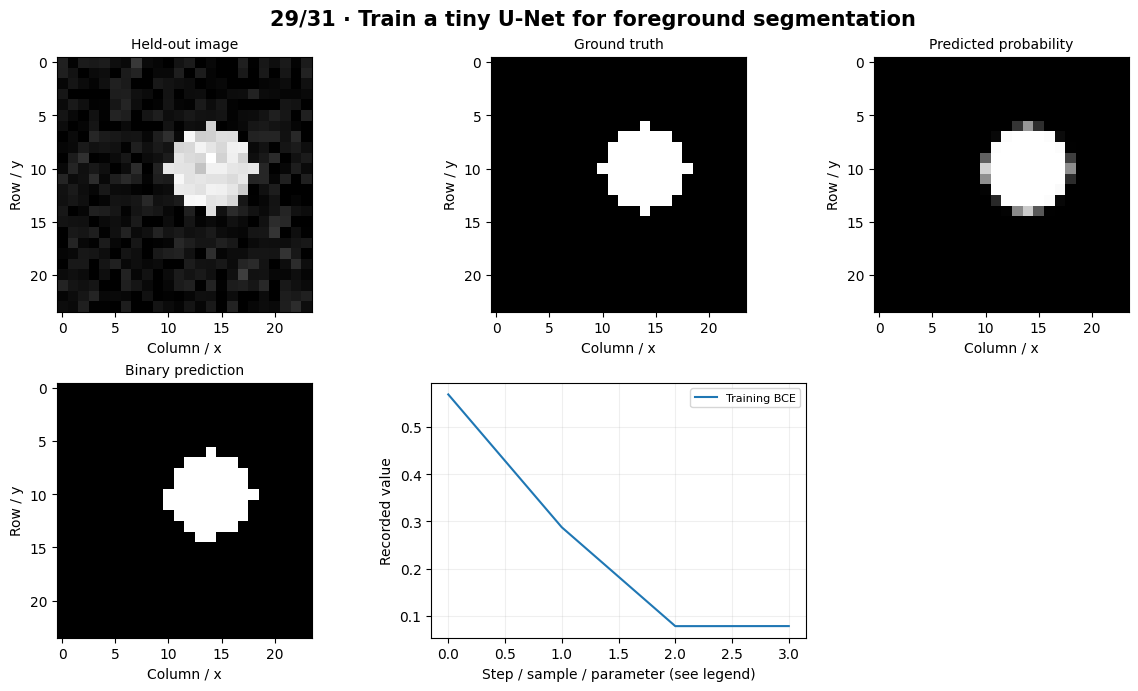

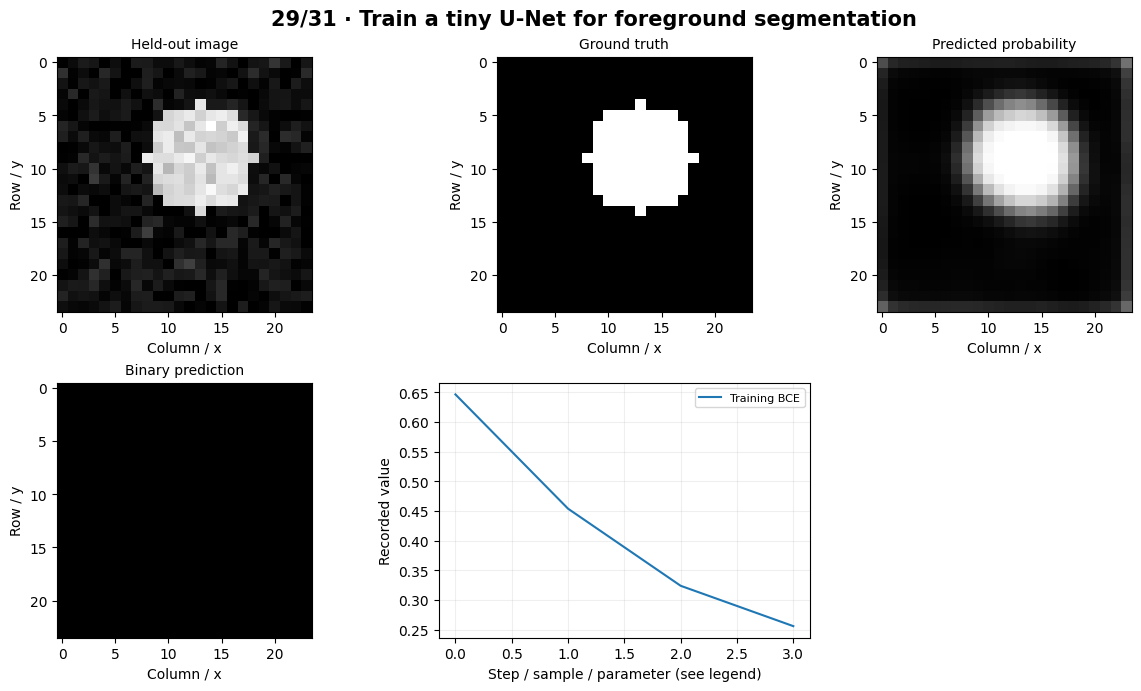

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Industrial Surface Segmentation**. Train and inspect a dense labeling model. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Colorful mask visualizations are not training targets unless colors are mapped consistently to integer class IDs.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Create a rare foreground class and compare unweighted loss with a documented weighting scheme. Report per-class IoU rather than only the mean.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a semantic segmentation experiment with class-map validation, ignored-pixel handling and a per-class test report.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A fully convolutional network replaces image-level classification with spatial logits. For C mutually exclusive classes, logits have shape N×C×H×W and targets typically have integer IDs N×H×W. Binary one-channel segmentation is a special case and uses a different target contract.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **U-Net, DeepLab and context** in this chapter.

[Primary reference](https://arxiv.org/abs/1606.00915) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)